In [3]:
%pip install yfinance scikit-learn hmmlearn matplotlib

  Using cached scikit_learn-1.9.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached hmmlearn-0.3.3.tar.gz (78 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached scipy-1.18.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.22.1-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (9.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.22.1-py3-none-any.whl (454 kB)
Using cached scipy-1.18.0-cp314-cp314-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  error: subprocess-exited-with-error
  
  × 

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import joblib

from sklearn.preprocessing import StandardScaler
from hmmlearn.hmm import GaussianHMM

import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'joblib'

In [ ]:

data = yf.download(
    "^NSEI",
    start="2010-01-01",
    end="2026-01-01",
    auto_adjust=True
)
data.head()
print(data.columns)
print(data.shape)

[*********************100%***********************]  1 of 1 completed

MultiIndex([( 'Close', '^NSEI'),
            (  'High', '^NSEI'),
            (   'Low', '^NSEI'),
            (  'Open', '^NSEI'),
            ('Volume', '^NSEI')],
           names=['Price', 'Ticker'])
(3929, 5)


In [ ]:
# Flatten MultiIndex columns
data.columns = data.columns.get_level_values(0)
# Convert Date index to normal column
data = data.reset_index()
# Remove column index name
data.columns.name = None
# Sort by date
data = data.sort_values("Date").reset_index(drop=True)
# Save clean dataset
data.to_csv("clean_data.csv", index=False)
print(data.columns)
print(data.shape)

data.head()

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
(3929, 6)


,Date,Close,High,Low,Open,Volume
0,2010-01-04,5232.200195,5238.450195,5167.100098,5200.899902,0
1,2010-01-05,5277.899902,5288.350098,5242.399902,5277.149902,0
2,2010-01-06,5281.799805,5310.850098,5260.049805,5278.149902,0
3,2010-01-07,5263.100098,5302.549805,5244.750000,5281.799805,0
4,2010-01-08,5244.750000,5276.750000,5234.700195,5264.250000,0


In [ ]:

# Calculate log returns
data["Log_Return"] = np.log(
    data["Close"] / data["Close"].shift(1)
)
# 20-day rolling volatility
data["Volatility"] = data["Log_Return"].rolling(window=20).std()
# Range Feature
data["Range"] = (
    data["High"] - data["Low"]
) / data["Close"]
# Remove NaN values created by rolling window
data = data.dropna().reset_index(drop=True)


In [ ]:
features = data[[
    "Date",
    "Log_Return",
    "Volatility",
    "Range"
]].copy()
features.to_csv("features.csv", index=False)
print(features.head())
print(features.shape)

        Date  Log_Return  Volatility     Range
0 2010-02-02   -0.014307    0.010228  0.028374
1 2010-02-03    0.020847    0.011324  0.023957
2 2010-02-04   -0.017695    0.011713  0.020422
3 2010-02-05   -0.026497    0.012716  0.028536
4 2010-02-08    0.008809    0.013107  0.025975
(3909, 4)


In [ ]:

X = features[["Log_Return", "Volatility","Range"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled[:5])
print(X_scaled.shape)


[[-1.41215936  0.19387461  2.10005736]
 [ 1.95687094  0.4265765   1.54111754]
 [-1.73684119  0.50931917  1.09385911]
 [-2.5804056   0.7221471   2.12050025]
 [ 0.80318343  0.80531067  1.79646891]]
(3909, 3)


In [ ]:

hmm_model = GaussianHMM(
    n_components=6,
    covariance_type="full",
    n_iter=100,
    random_state=42
)

hmm_model.fit(X_scaled)
log_likelihood = hmm_model.score(X_scaled)
print("Training completed")
print("Number of states:", hmm_model.n_components)
print("Log Likelihood:", log_likelihood)


Training completed
Number of states: 6
Log Likelihood: -7746.280814666471


In [ ]:


joblib.dump(
    hmm_model,
    "hmm_model.pkl"
)

['hmm_model.pkl']

In [ ]:
print("State Means:")
print(hmm_model.means_)
print("\nTransition Matrix:")
print(hmm_model.transmat_)


State Means:
[[ 0.02733472 -0.53839167 -0.32087329]
 [-0.06608254  0.26909592  0.24009481]
 [-0.00430246 -0.1719355  -0.1544218 ]
 [-0.10094974  3.80158909  3.15369797]
 [ 0.05832644  1.11357863  0.52572314]
 [ 0.01537313 -0.87644793 -0.54971451]]

Transition Matrix:
[[9.20783624e-001 5.12032316e-028 3.66695909e-002 8.91766640e-003
  2.52180815e-135 3.36291190e-002]
 [4.63798339e-005 9.22790779e-001 4.98539294e-002 6.33230334e-003
  2.09766086e-002 1.85238602e-021]
 [4.22304611e-002 4.10532747e-002 9.11952120e-001 4.75115836e-003
  3.34731561e-094 1.29856223e-005]
 [3.16140467e-002 6.77133689e-002 4.44902957e-002 7.77327864e-001
  7.88544250e-002 1.75452901e-051]
 [1.70895490e-003 3.74627151e-002 5.08922537e-044 2.57012914e-003
  9.58258201e-001 1.05670009e-027]
 [3.65397826e-002 1.36184960e-066 5.46828643e-018 1.93716717e-003
  2.96468629e-186 9.61523050e-001]]


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
features.to_csv(
    "/content/drive/MyDrive/features.csv",
    index=False
)

print("features.csv saved")

features.csv saved


In [ ]:
states = hmm_model.predict(X_scaled)

features["State"] = states

print("\nState Counts:")
print(features["State"].value_counts())

print("\nState Statistics:")
print(
    features.groupby("State")[
        ["Log_Return", "Volatility", "Range"]
    ].mean()
)

states_df = features[
    ["Date", "State"]
].copy()


State Counts:
State
2    872
1    826
0    824
5    713
4    585
3     89
Name: count, dtype: int64

State Statistics:
       Log_Return  Volatility     Range
State                                  
0        0.000600    0.006785  0.009310
1       -0.000359    0.010596  0.013714
2        0.000483    0.008515  0.010521
3       -0.000598    0.027229  0.036571
4        0.001081    0.014553  0.015951
5        0.000668    0.005197  0.007397


In [ ]:
states_df.to_csv("states.csv", index=False)

In [ ]:
states_df.to_csv(
    "/content/drive/MyDrive/states.csv",
    index=False
)
print("states.csv saved successfully")

states.csv saved successfully


In [ ]:
state_probs = hmm_model.predict_proba(
    X_scaled
)
prob_df = pd.DataFrame(
    state_probs,
    columns=[
        f"State_{i}"
        for i in range(
            hmm_model.n_components
        )
    ]
)
prob_df["Date"] = features["Date"]
prob_df.to_csv(
    "state_probabilities.csv",
    index=False
)
prob_df.to_csv(
    "/content/drive/MyDrive/state_probabilities.csv",
    index=False
)
print("state_probabilities.csv saved")

state_probabilities.csv saved


In [ ]:
transition_df = pd.DataFrame(
    hmm_model.transmat_
)

transition_df.to_csv(
    "transition_matrix.csv",
    index=False
)
transition_df.to_csv(
    "/content/drive/MyDrive/transition_matrix.csv",
    index=False
)
print("transition_matrix.csv saved")

transition_matrix.csv saved


In [ ]:
import numpy as np

stats = []

for state in range(
    hmm_model.n_components
):

    state_data = features[
        features["State"] == state
    ]

    mean_return = (
        state_data["Log_Return"]
        .mean()
    )

    volatility = (
        state_data["Log_Return"]
        .std()
    )

    sharpe = (
        mean_return /
        volatility
        if volatility > 0
        else np.nan
    )

    downside = state_data[
        state_data["Log_Return"] < 0
    ]["Log_Return"]

    sortino = (
        mean_return /
        downside.std()
        if len(downside) > 1
        else np.nan
    )

    stats.append({
        "State": state,
        "Frequency": len(state_data),
        "Mean_Return": mean_return,
        "Volatility": volatility,
        "Sharpe_Ratio": sharpe,
        "Sortino_Ratio": sortino
    })

state_characteristics = pd.DataFrame(
    stats
)

state_characteristics.to_csv(
    "state_characteristics.csv",
    index=False
)
state_characteristics.to_csv(
    "/content/drive/MyDrive/state_characteristics.csv",
    index=False
)
state_characteristics

,State,Frequency,Mean_Return,Volatility,Sharpe_Ratio,Sortino_Ratio
0,0,824,0.000600,0.006851,0.087551,0.141315
1,1,826,-0.000359,0.010727,-0.033510,-0.052450
2,2,872,0.000483,0.008286,0.058334,0.090415
3,3,89,-0.000598,0.034712,-0.017239,-0.020982
4,4,585,0.001081,0.013400,0.080660,0.121607
5,5,713,0.000668,0.005357,0.124653,0.215915


In [ ]:
persistence = []

for i in range(
    hmm_model.n_components
):

    pii = hmm_model.transmat_[i, i]

    persistence.append({
        "State": i,
        "Persistence": pii,
        "Expected_Duration":
            1/(1-pii)
    })

persistence_df = pd.DataFrame(
    persistence
)

persistence_df.to_csv(
    "persistence_metrics.csv",
    index=False
)
persistence_df.to_csv(
    "/content/drive/MyDrive/persistence_metrics.csv",
    index=False
)
persistence_df

,State,Persistence,Expected_Duration
0,0,0.920784,12.623652
1,1,0.922791,12.951821
2,2,0.911952,11.357457
3,3,0.777328,4.490908
4,4,0.958258,23.956802
5,5,0.961523,25.989586


In [ ]:
import joblib
joblib.dump(
    hmm_model,
    "hmm_model.pkl"
)
joblib.dump(
    scaler,
    "scaler.pkl"
)
print("Model and scaler saved")

Model and scaler saved


In [ ]:
plot_data = data.copy()

plot_data = plot_data.iloc[-len(states):].copy()

plot_data["State"] = states

plot_data.head()

,Date,Close,High,Low,Open,Volume,Log_Return,Volatility,Range,State
0,2010-02-02,4830.100098,4951.149902,4814.100098,4907.850098,0,-0.014307,0.010228,0.028374,1
1,2010-02-03,4931.850098,4949.149902,4831.000000,4831.000000,0,0.020847,0.011324,0.023957,1
2,2010-02-04,4845.350098,4931.299805,4832.350098,4931.299805,0,-0.017695,0.011713,0.020422,1
3,2010-02-05,4718.649902,4827.000000,4692.350098,4819.649902,0,-0.026497,0.012716,0.028536,4
4,2010-02-08,4760.399902,4799.049805,4675.399902,4755.350098,0,0.008809,0.013107,0.025975,4


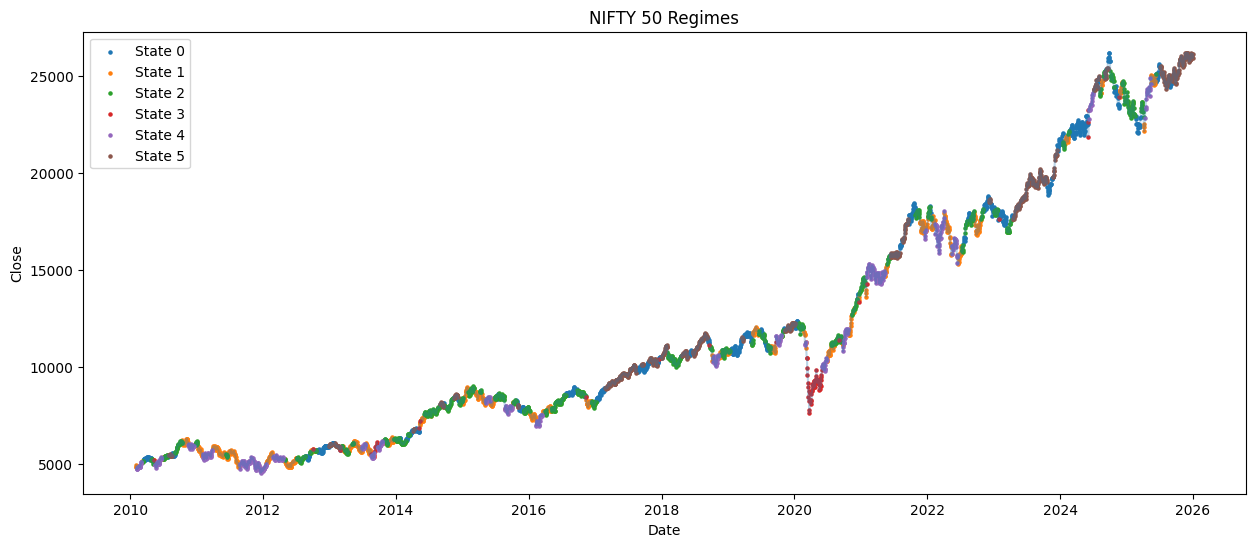

<Figure size 640x480 with 0 Axes>

In [ ]:


plt.figure(figsize=(15,6))

for state in sorted(plot_data["State"].unique()):
    mask = plot_data["State"] == state

    plt.scatter(
        plot_data.loc[mask, "Date"],
        plot_data.loc[mask, "Close"],
        s=5,
        label=f"State {state}"
    )

plt.plot(
    plot_data["Date"],
    plot_data["Close"],
    alpha=0.3
)

plt.title("NIFTY 50 Regimes")
plt.xlabel("Date")
plt.ylabel("Close")
plt.legend()
plt.show()
plt.savefig(
    "/content/drive/MyDrive/plot_4state_range.png",
    dpi=300,
    bbox_inches="tight"
)

In [ ]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'drive', 'features.csv', 'clean_data.csv', 'state_probabilities.csv', 'transition_matrix.csv', 'state_characteristics.csv', 'states.csv', 'scaler.pkl', 'hmm_model.pkl', 'persistence_metrics.csv', 'sample_data']
